# Importação dos Pacotes

In [84]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm # Para modelos estatísticos (como regressão)
from statsmodels.stats.diagnostic import het_breuschpagan # Teste de Breusch-Pagan para homocedasticidade
from statsmodels.stats.outliers_influence import variance_inflation_factor # Para VIF (não usado no modelo simples, mas útil para multi)
from statsmodels.stats.diagnostic import lilliefors # Teste de Lilliefors para normalidade (alternativa a Shapiro-Wilk)
import scipy.stats as stats # Para funções estatísticas, incluindo testes de normalidade

# Análise Descritiva

In [85]:
df = pd.read_csv(
    r'C:\Users\negri\OneDrive\Documentos\GitHub\Hashtag_AnaliseDados\Python\Cursos\PUC Ciência de Dados\Projetos\Modelos de Regressão\Aulas\02.5_Atividade\Base\preco_carro (3).csv', 
    sep=',', 
    encoding='latin-1'
)

df.head(5)

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


In [86]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   v.id           1000 non-null   int64  
 1   on road old    1000 non-null   int64  
 2   on road now    1000 non-null   int64  
 3   years          1000 non-null   int64  
 4   km             1000 non-null   int64  
 5   rating         1000 non-null   int64  
 6   condition      1000 non-null   int64  
 7   economy        1000 non-null   int64  
 8   top speed      1000 non-null   int64  
 9   hp             1000 non-null   int64  
 10  torque         1000 non-null   int64  
 11  current price  1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


v.id             0
on road old      0
on road now      0
years            0
km               0
rating           0
condition        0
economy          0
top speed        0
hp               0
torque           0
current price    0
dtype: int64

In [87]:
df = df.fillna(0) # Preenche valores ausentes com 0 (Caso tenha algum)

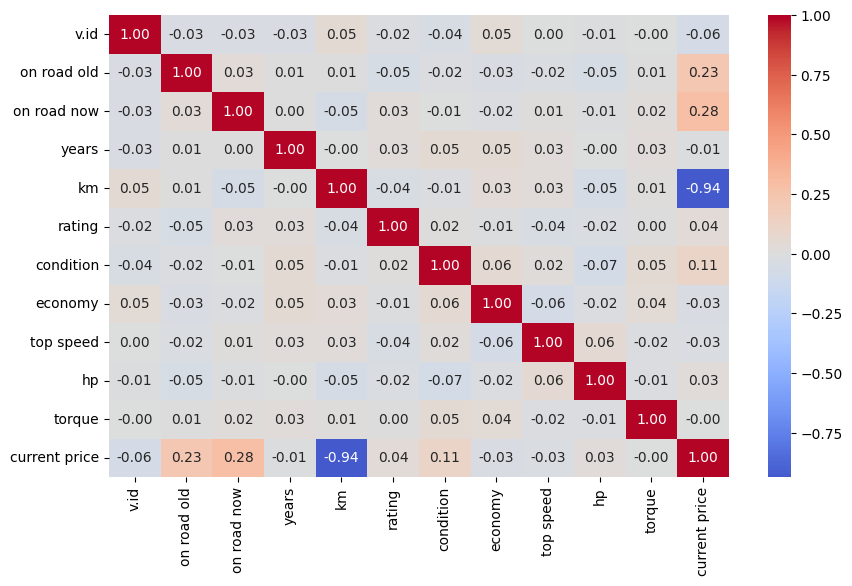

In [88]:
plt.figure(figsize=(10,6))
#sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
sns.heatmap(df.corr(),annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.show()

# Análise das Correlações

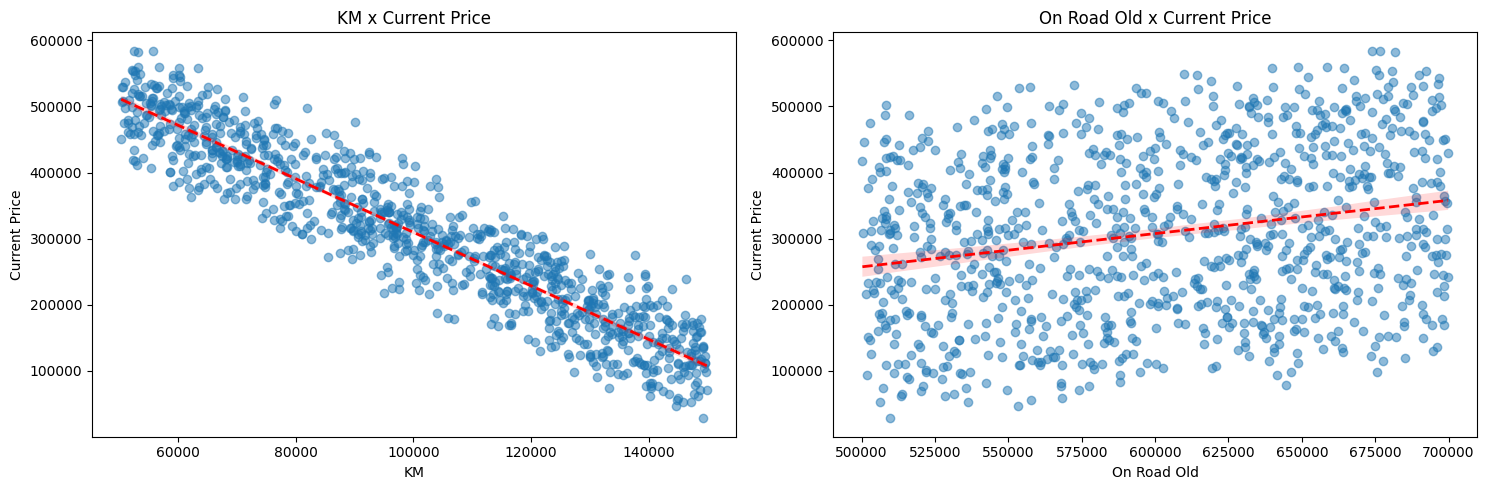

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
sns.regplot(
    data=df,
    x='km',
    y='current price',
    scatter_kws={'alpha': 0.5},
    line_kws={'linewidth': 2, 'color':'red', 'linestyle':'--'},
    ax=ax[0]
)
ax[0].set_title('KM x Current Price')
ax[0].set_xlabel('KM')
ax[0].set_ylabel('Current Price')

sns.regplot(
    data=df,
    x='on road old',
    y='current price',
    scatter_kws={'alpha': 0.5},
    line_kws={'linewidth': 2, 'color':'red', 'linestyle':'--'},
    ax=ax[1]
)

ax[1].set_title('On Road Old x Current Price')
ax[1].set_xlabel('On Road Old')
ax[1].set_ylabel('Current Price')
plt.tight_layout()
plt.show()

# Modelo de Regressão com Todas as Variáveis

## Criação do Modelo

In [90]:
# Criando Modelo de Regressão usando todas as variáveis
Y = df['current price'] # Variavel Dependente target
X = df.drop(columns=['current price']) # Variáveis Independentes (todas as outras colunas)

X = pd.get_dummies(X, drop_first=True, dtype=int) # Tratar variáveis categóricas - Modelos de regressão não aceitam texto diretamente.
X = sm.add_constant(X) # Adiciona uma constante 



In [91]:
modelo_todas_variaveis = sm.OLS(Y, X).fit()
print(modelo_todas_variaveis.summary())

residuos = modelo_todas_variaveis.resid

                            OLS Regression Results                            
Dep. Variable:          current price   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.883e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:00:47   Log-Likelihood:                -10488.
No. Observations:                1000   AIC:                         2.100e+04
Df Residuals:                     988   BIC:                         2.106e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.427e+04   6078.759     -2.347      

## Análise de Coeficientes - Mostra o quanto a previsão muda quando uma variável aumenta uma unidade, mantendo as demais constantes

In [92]:
# Isso mostra o quanto a previsão muda quando uma variável aumenta uma unidade, mantendo as demais constantes.
coeficientes = pd.DataFrame({
    'Variavel': modelo_todas_variaveis.params.index,
    'Coeficiente': modelo_todas_variaveis.params.values,
    'P_Value': modelo_todas_variaveis.pvalues.values
})

coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    key=lambda x: abs(x),
    ascending=False
)

coeficientes_grandes = coeficientes[
    coeficientes['Coeficiente'].abs() > 1000
]

if not coeficientes_grandes.empty:
    print(
        "\nExistem variáveis com coeficiente absoluto superior a 1000:"
    )
    print(
        coeficientes_grandes[['Variavel', 'Coeficiente', 'P_Value']]
    )


Existem variáveis com coeficiente absoluto superior a 1000:
    Variavel   Coeficiente        P_Value
0      const -14268.819194   1.910536e-02
7  condition   4631.315139  7.370600e-254
4      years  -1618.442887   1.376051e-22


## Multicolinearidade - Indica o quanto a variância dos coeficientes é inflada devido à correlação entre as variáveis independentes. VIF > 10 é um sinal de multicolinearidade severa

In [93]:
# Multicolinearidade: VIF (Variance Inflation Factor) - Indica o quanto a variância dos coeficientes é inflada devido à correlação entre as variáveis independentes. VIF > 10 é um sinal de multicolinearidade severa.
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variavel"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)
if vif["VIF"].max()>10:
    print("Indica que há multicolinearidade entre as variáveis, afetando a estabilidade dos coeficientes")

Indica que há multicolinearidade entre as variáveis, afetando a estabilidade dos coeficientes


## Homocedasticidade - Verifica se os resíduos têm variância constante. Um p-valor baixo (geralmente < 0.05) indica heterocedasticidade, ou seja, variância dos resíduos não é constante

In [94]:
# Homocedasticidade: Teste de Breusch-Pagan - Verifica se os resíduos têm variância constante. Um p-valor baixo (geralmente < 0.05) indica heterocedasticidade, ou seja, variância dos resíduos não é constante.
bp_test = het_breuschpagan(
    modelo_todas_variaveis.resid,
    modelo_todas_variaveis.model.exog
)

bp_resultado = pd.DataFrame({
    'Teste': [
        'LM Statistic',
        'LM p-value',
        'F Statistic',
        'F p-value'
    ],
    'Valor': bp_test
})

print("\nBreusch-Pagan:")
print(bp_resultado)


Breusch-Pagan:
          Teste         Valor
0  LM Statistic  1.634053e+02
1    LM p-value  2.675957e-29
2   F Statistic  1.754346e+01
3     F p-value  4.134182e-32


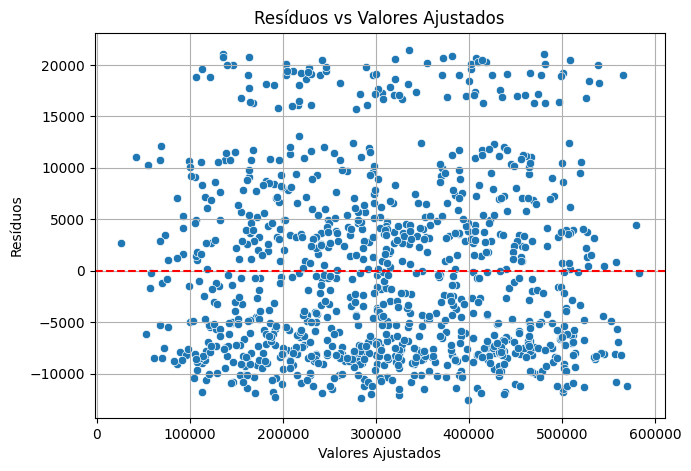

In [95]:
# Homocedasticidade: Teste de Breusch-Pagan 
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

plt.figure(figsize=(25,5))
plt.subplot(1,3,1)
sns.scatterplot(x=modelo_todas_variaveis.fittedvalues, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs Valores Ajustados')
plt.grid(True)
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.show()

## Teste de Wilk Shapiro - Verifica se os resíduos seguem uma distribuição normal. H0: Os resíduos seguem uma distribuição normal. H1: Os resíduos não seguem uma distribuição normal.

In [96]:
# --- Teste de Normalidade dos Resíduos (Shapiro-Wilk) - Verifica se os resíduos seguem uma distribuição normal. H0: Os resíduos seguem uma distribuição normal. H1: Os resíduos não seguem uma distribuição normal.
def run_shapiro_wilk_test(model_name, residuals):
    
    """
        Executa o teste de Shapiro-Wilk para verificar a normalidade dos resíduos.
        * H0: Os resíduos seguem uma distribuição normal.
        * H1: Os resíduos não seguem uma distribuição normal.
    """
    
    estatistica_shapiro, p_shapiro = stats.shapiro(residuals)
    print(f"\n--- Teste de Shapiro-Wilk para {model_name} ---")
    print(f"Estatística de Teste: {estatistica_shapiro:.4f}")
    print(f"P-valor: {p_shapiro:.4f}")

    if p_shapiro < 0.05:
        print(f"Conclusão: Rejeitamos H0. Os resíduos do modelo {model_name} não seguem uma distribuição normal.")
    else:
        print(f"Conclusão: Não rejeitamos H0. Os resíduos do modelo {model_name} seguem uma distribuição normal.")

print("\n--- Testes de Normalidade dos Resíduos (Shapiro-Wilk) ---")
run_shapiro_wilk_test('Todas as Variáveis', residuos)


--- Testes de Normalidade dos Resíduos (Shapiro-Wilk) ---

--- Teste de Shapiro-Wilk para Todas as Variáveis ---
Estatística de Teste: 0.9202
P-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos do modelo Todas as Variáveis não seguem uma distribuição normal.


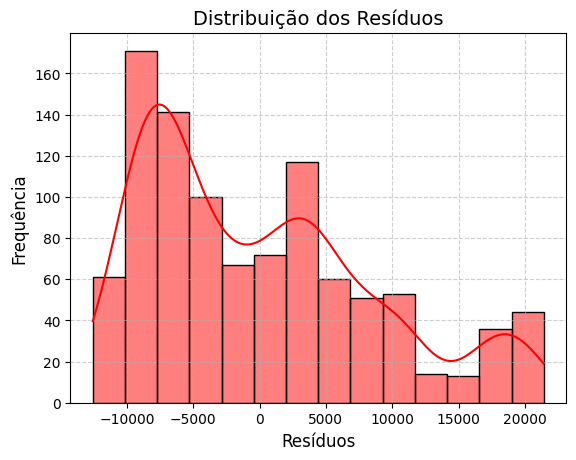

In [97]:
sns.histplot(modelo_todas_variaveis.resid, kde=True, color='red')
plt.title('Distribuição dos Resíduos', fontsize=14)
plt.xlabel('Resíduos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Frequência', fontsize=12)
plt.show()

## Teste da Normalidade dos Resíduos


--- Análise Gráfica de Normalidade (Q-Q Plot) ---


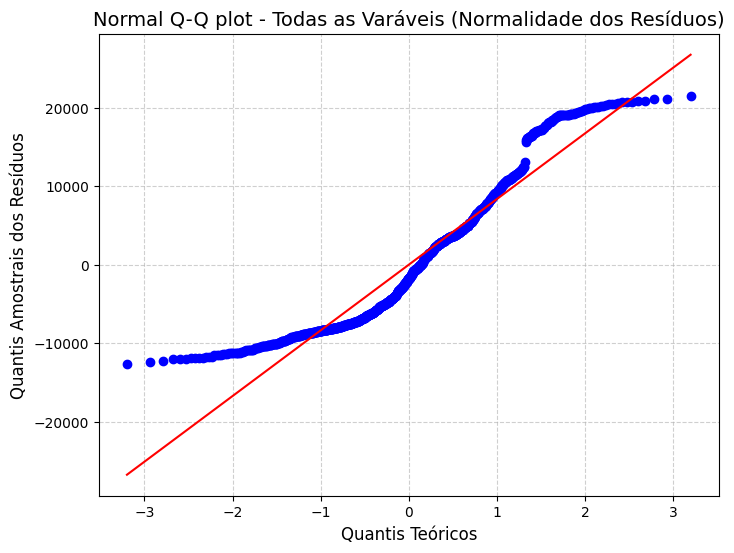


Interpretação dos Q-Q Plots:
1. Se os pontos do Q-Q plot estiverem aproximadamente alinhados ao longo da linha diagonal, isso sugere que os resíduos seguem uma distribuição normal.
2. Desvios significativos dos pontos em relação à linha diagonal, especialmente nas caudas, indicam que os resíduos podem não seguir uma distribuição normal.


In [98]:
# Interpretação dos Testes de Normalidade dos Resíduos
def plot_qq(model_name, residuals):
    # Gera um QQ-plot para verificar a normalidade dos resíduos.
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"Normal Q-Q plot - {model_name} (Normalidade dos Resíduos)", fontsize=14)
    plt.xlabel('Quantis Teóricos', fontsize=12)
    plt.ylabel('Quantis Amostrais dos Resíduos', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

print("\n--- Análise Gráfica de Normalidade (Q-Q Plot) ---")
plot_qq('Todas as Varáveis', residuos)

print("\nInterpretação dos Q-Q Plots:")
print("1. Se os pontos do Q-Q plot estiverem aproximadamente alinhados ao longo da linha diagonal, isso sugere que os resíduos seguem uma distribuição normal.")
print("2. Desvios significativos dos pontos em relação à linha diagonal, especialmente nas caudas, indicam que os resíduos podem não seguir uma distribuição normal.")

## Separação dos Modelos de Teste e Treino

In [99]:
from sklearn.model_selection import train_test_split
# Dividindo os dados em conjunto de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [100]:
from sklearn.linear_model import LinearRegression
# Criando e Treinando o Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0. , 0.71, 0.5 ,...,-20.86, 31.06, -2.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['const','v.id','on road old',...,'top speed','hp','torque']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.415e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [101]:
# Previsões do Modelo para o conjunto de teste
y_pred = modelo.predict(X_test) 

## Avaliação do Modelo de Regressão

In [102]:
# Avaliação do Modelo
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, y_pred))
if mean_absolute_error(y_test, y_pred)<1000:
    print("O modelo tem um erro médio de menos de 1000, o que pode ser considerado um bom desempenho dependendo do contexto\n\t")
else:
    print("O modelo tem um erro médio de mais de 1000, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.\n\t")

print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
if mean_squared_error(y_test, y_pred) ** 0.5 < 1500:
    print("O modelo tem um erro quadrático médio de menos de 1500, o que pode ser considerado um bom desempenho dependendo do contexto\n\t")
else:
    print("O modelo tem um erro quadrático médio de mais de 1500, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.\n\t")

print("R²:", r2_score(y_test, y_pred))
if r2_score(y_test, y_pred) > 0.7:
    print("O modelo explica mais de 70% da variabilidade dos dados, o que é um bom desempenho.")
elif r2_score(y_test, y_pred) > 0.5:
    print("O modelo explica entre 50% e 70% da variabilidade dos dados, o que pode ser considerado um desempenho razoável.")

MAE: 7579.220224029338
O modelo tem um erro médio de mais de 1000, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.
	
RMSE: 8998.840486430428
O modelo tem um erro quadrático médio de mais de 1500, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.
	
R²: 0.995182959928768
O modelo explica mais de 70% da variabilidade dos dados, o que é um bom desempenho.


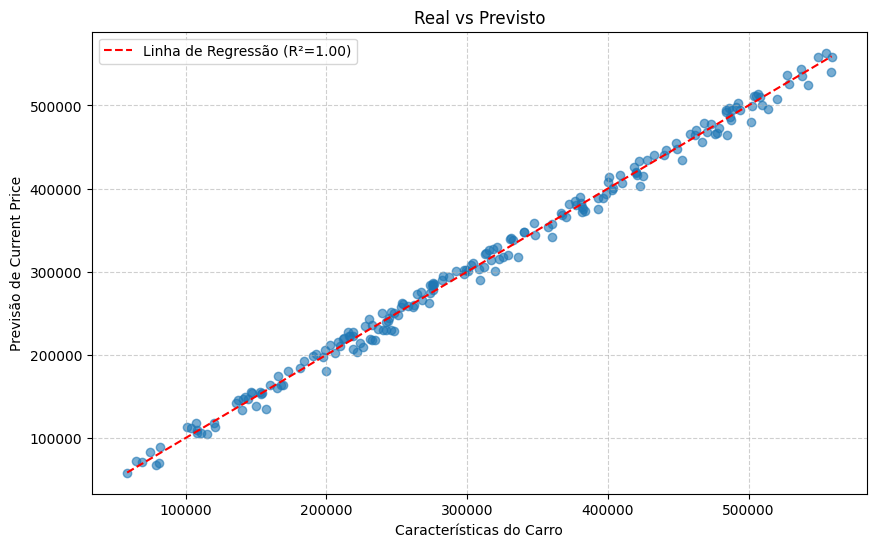

In [103]:
# Visualizando os resultados reais vs previstos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red',
    label=f'Linha de Regressão (R²={modelo_todas_variaveis.rsquared:.2f})'
)
plt.xlabel('Características do Carro') # X = df.drop(columns=['current price'])
plt.ylabel('Previsão de Current Price') # Y = df['current price']
plt.title('Real vs Previsto')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

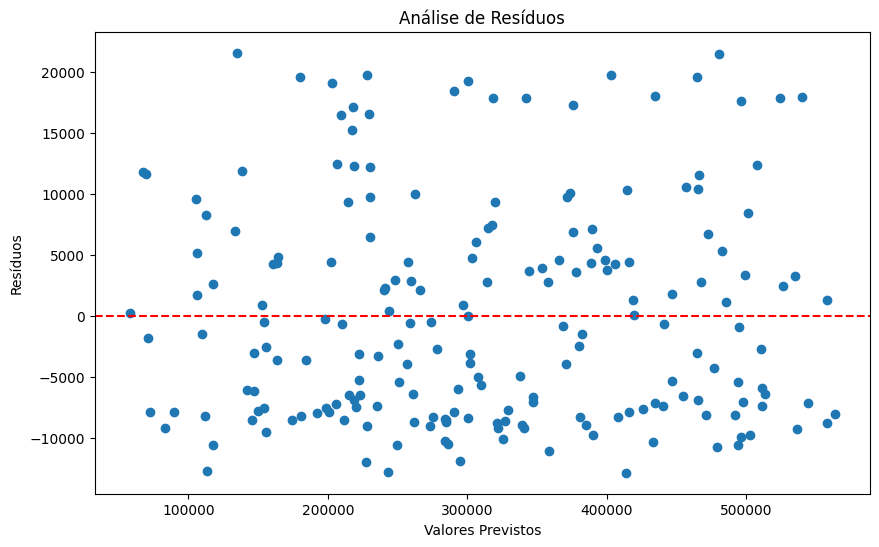

In [104]:
residuos = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle='--', color='red')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Análise de Resíduos')
plt.show()

# Modelo de Regressão com 3 Variáveis e 5 Variáveis

## Criação do Modelo

In [105]:
# Criando Modelo de Regressão usando todas as variáveis
Y = df['current price'] # Variavel Dependente target
X = df[['on road old','on road now', 'condition']] # 3ª Variáveis Independentes (variáveis selecionadas com base na correlação e análise de coeficientes)
# X = df[['on road old','on road new', 'condition', 'condition', 'km']] # 5ª Variáveis Independentes (variáveis selecionadas com base na correlação e análise de coeficientes)

X = pd.get_dummies(X, drop_first=True, dtype=int) # Tratar variáveis categóricas - Modelos de regressão não aceitam texto diretamente.
X = sm.add_constant(X) # Adiciona uma constante 


In [106]:
modelo_todas_variaveis = sm.OLS(Y, X).fit()
print(modelo_todas_variaveis.summary())

residuos = modelo_todas_variaveis.resid

                            OLS Regression Results                            
Dep. Variable:          current price   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     55.47
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           3.68e-33
Time:                        19:00:49   Log-Likelihood:                -13086.
No. Observations:                1000   AIC:                         2.618e+04
Df Residuals:                     996   BIC:                         2.620e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           -5e+05   6.39e+04     -7.822      

## Análise de Coeficientes - Mostra o quanto a previsão muda quando uma variável aumenta uma unidade, mantendo as demais constantes

In [107]:
# Isso mostra o quanto a previsão muda quando uma variável aumenta uma unidade, mantendo as demais constantes.
coeficientes = pd.DataFrame({
    'Variavel': modelo_todas_variaveis.params.index,
    'Coeficiente': modelo_todas_variaveis.params.values,
    'P_Value': modelo_todas_variaveis.pvalues.values
})

coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    key=lambda x: abs(x),
    ascending=False
)

coeficientes_grandes = coeficientes[
    coeficientes['Coeficiente'].abs() > 1000
]

if not coeficientes_grandes.empty:
    print(
        "\nExistem variáveis com coeficiente absoluto superior a 1000:"
    )
    print(
        coeficientes_grandes[['Variavel', 'Coeficiente', 'P_Value']]
    )


Existem variáveis com coeficiente absoluto superior a 1000:
    Variavel    Coeficiente       P_Value
0      const -499987.677974  1.320982e-14
3  condition    5134.707147  9.403903e-05


## Multicolinearidade - Indica o quanto a variância dos coeficientes é inflada devido à correlação entre as variáveis independentes. VIF > 10 é um sinal de multicolinearidade severa

In [108]:
# Multicolinearidade: VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variavel"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)
if vif["VIF"].max()>10:
    print("Indica que há multicolinearidade entre as variáveis, afetando a estabilidade dos coeficientes")

Indica que há multicolinearidade entre as variáveis, afetando a estabilidade dos coeficientes


In [109]:
# Homocedasticidade: Teste de Breusch-Pagan 
bp_test = het_breuschpagan(
    modelo_todas_variaveis.resid,
    modelo_todas_variaveis.model.exog
)

bp_resultado = pd.DataFrame({
    'Teste': [
        'LM Statistic',
        'LM p-value',
        'F Statistic',
        'F p-value'
    ],
    'Valor': bp_test
})

print("\nBreusch-Pagan:")
print(bp_resultado)


Breusch-Pagan:
          Teste     Valor
0  LM Statistic  2.877564
1    LM p-value  0.410890
2   F Statistic  0.958108
3     F p-value  0.411844


## Homocedasticidade - Verifica se os resíduos têm variância constante. Um p-valor baixo (geralmente < 0.05) indica heterocedasticidade, ou seja, variância dos resíduos não é constante

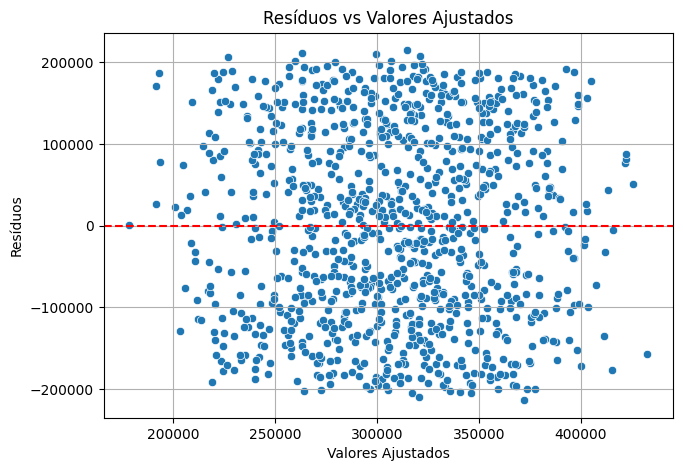

In [110]:
# Homocedasticidade: Teste de Breusch-Pagan 
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

plt.figure(figsize=(25,5))
plt.subplot(1,3,1)
sns.scatterplot(x=modelo_todas_variaveis.fittedvalues, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs Valores Ajustados')
plt.grid(True)
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.show()

## Teste de Wilk Shapiro - Verifica se os resíduos seguem uma distribuição normal. H0: Os resíduos seguem uma distribuição normal. H1: Os resíduos não seguem uma distribuição normal.

In [111]:
# --- Teste de Normalidade dos Resíduos (Shapiro-Wilk)
def run_shapiro_wilk_test(model_name, residuals):
    
    """
        Executa o teste de Shapiro-Wilk para verificar a normalidade dos resíduos.
        * H0: Os resíduos seguem uma distribuição normal.
        * H1: Os resíduos não seguem uma distribuição normal.
    """
    
    estatistica_shapiro, p_shapiro = stats.shapiro(residuals)
    print(f"\n--- Teste de Shapiro-Wilk para {model_name} ---")
    print(f"Estatística de Teste: {estatistica_shapiro:.4f}")
    print(f"P-valor: {p_shapiro:.4f}")

    if p_shapiro < 0.05:
        print(f"Conclusão: Rejeitamos H0. Os resíduos do modelo {model_name} não seguem uma distribuição normal.")
    else:
        print(f"Conclusão: Não rejeitamos H0. Os resíduos do modelo {model_name} seguem uma distribuição normal.")

print("\n--- Testes de Normalidade dos Resíduos (Shapiro-Wilk) ---")
run_shapiro_wilk_test('Todas as Variáveis', residuos)


--- Testes de Normalidade dos Resíduos (Shapiro-Wilk) ---

--- Teste de Shapiro-Wilk para Todas as Variáveis ---
Estatística de Teste: 0.9535
P-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos do modelo Todas as Variáveis não seguem uma distribuição normal.


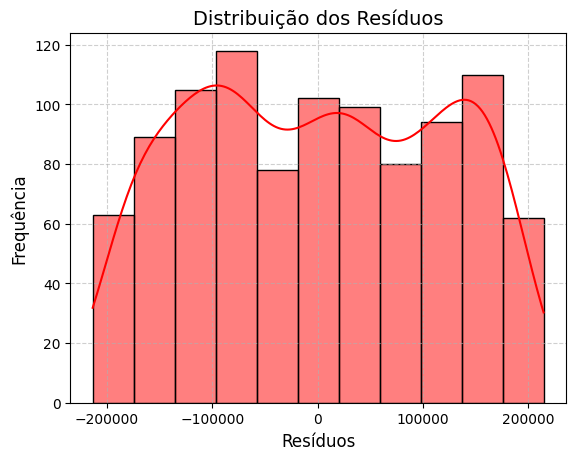

In [112]:
sns.histplot(modelo_todas_variaveis.resid, kde=True, color='red')
plt.title('Distribuição dos Resíduos', fontsize=14)
plt.xlabel('Resíduos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Frequência', fontsize=12)
plt.show()

## Teste da Normalidade dos Resíduos


--- Análise Gráfica de Normalidade (Q-Q Plot) ---


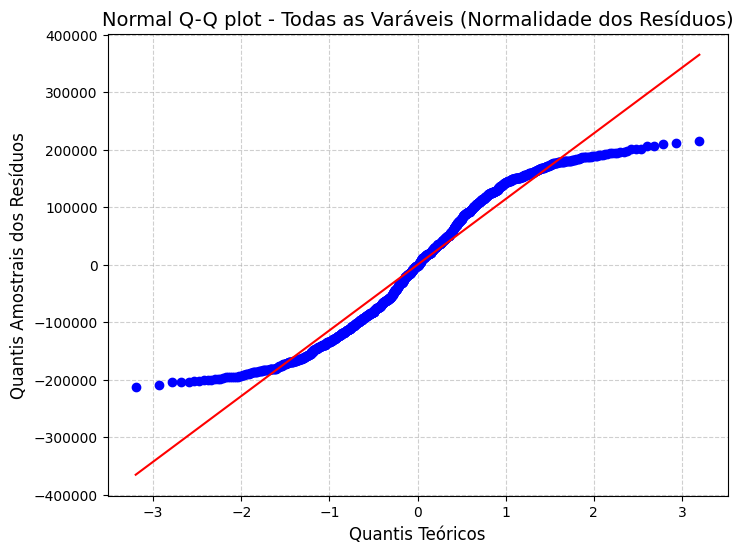


Interpretação dos Q-Q Plots:
1. Se os pontos do Q-Q plot estiverem aproximadamente alinhados ao longo da linha diagonal, isso sugere que os resíduos seguem uma distribuição normal.
2. Desvios significativos dos pontos em relação à linha diagonal, especialmente nas caudas, indicam que os resíduos podem não seguir uma distribuição normal.


In [113]:
# Interpretação dos Testes de Normalidade dos Resíduos
def plot_qq(model_name, residuals):
    # Gera um QQ-plot para verificar a normalidade dos resíduos.
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"Normal Q-Q plot - {model_name} (Normalidade dos Resíduos)", fontsize=14)
    plt.xlabel('Quantis Teóricos', fontsize=12)
    plt.ylabel('Quantis Amostrais dos Resíduos', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

print("\n--- Análise Gráfica de Normalidade (Q-Q Plot) ---")
plot_qq('Todas as Varáveis', residuos)

print("\nInterpretação dos Q-Q Plots:")
print("1. Se os pontos do Q-Q plot estiverem aproximadamente alinhados ao longo da linha diagonal, isso sugere que os resíduos seguem uma distribuição normal.")
print("2. Desvios significativos dos pontos em relação à linha diagonal, especialmente nas caudas, indicam que os resíduos podem não seguir uma distribuição normal.")

## Separação dos Modelos de Teste e Treino

In [114]:
from sklearn.model_selection import train_test_split
# Dividindo os dados em conjunto de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [115]:
from sklearn.linear_model import LinearRegression
# Criando e Treinando o Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. , 0.48, 0.57,4994.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['const','on road old','on road now','condition']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.625e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [116]:
# Previsões do Modelo para o conjunto de teste
y_pred = modelo.predict(X_test) 

## Avaliação do Modelo de Regressão

In [117]:
# Avaliação do Modelo
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, y_pred))
if mean_absolute_error(y_test, y_pred)<1000:
    print("O modelo tem um erro médio de menos de 1000, o que pode ser considerado um bom desempenho dependendo do contexto\n\t")
else:
    print("O modelo tem um erro médio de mais de 1000, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.\n\t")

print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
if mean_squared_error(y_test, y_pred) ** 0.5 < 1500:
    print("O modelo tem um erro quadrático médio de menos de 1500, o que pode ser considerado um bom desempenho dependendo do contexto\n\t")
else:
    print("O modelo tem um erro quadrático médio de mais de 1500, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.\n\t")

print("R²:", r2_score(y_test, y_pred))
if r2_score(y_test, y_pred) > 0.7:
    print("O modelo explica mais de 70% da variabilidade dos dados, o que é um bom desempenho.")
elif r2_score(y_test, y_pred) > 0.5:
    print("O modelo explica entre 50% e 70% da variabilidade dos dados, o que pode ser considerado um desempenho razoável.")

MAE: 102675.52447777036
O modelo tem um erro médio de mais de 1000, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.
	
RMSE: 118337.72841156942
O modelo tem um erro quadrático médio de mais de 1500, o que pode indicar que o modelo tem um desempenho ruim ou que os dados são muito variáveis.
	
R²: 0.16698349059691553


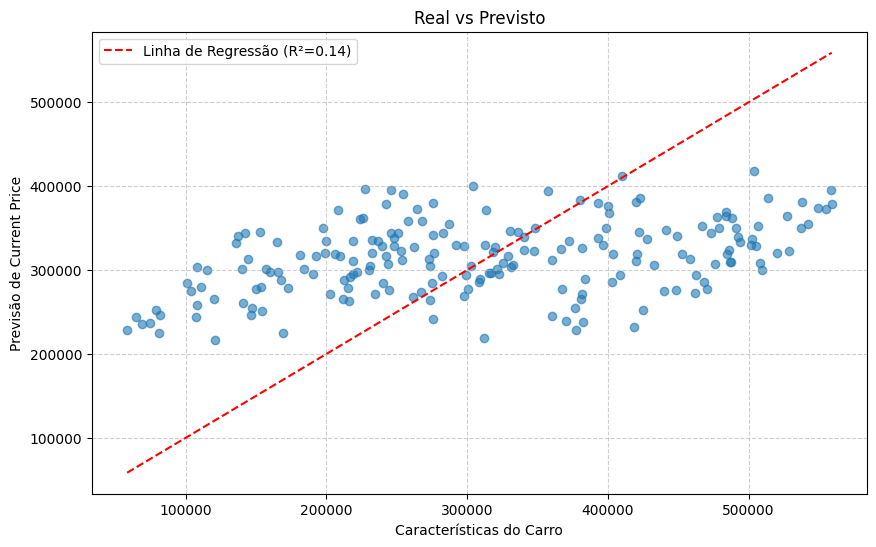

In [118]:
# Visualizando os resultados reais vs previstos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red',
    label=f'Linha de Regressão (R²={modelo_todas_variaveis.rsquared:.2f})'
)
plt.xlabel('Características do Carro') # X = df.drop(columns=['current price'])
plt.ylabel('Previsão de Current Price') # Y = df['current price']
plt.title('Real vs Previsto')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

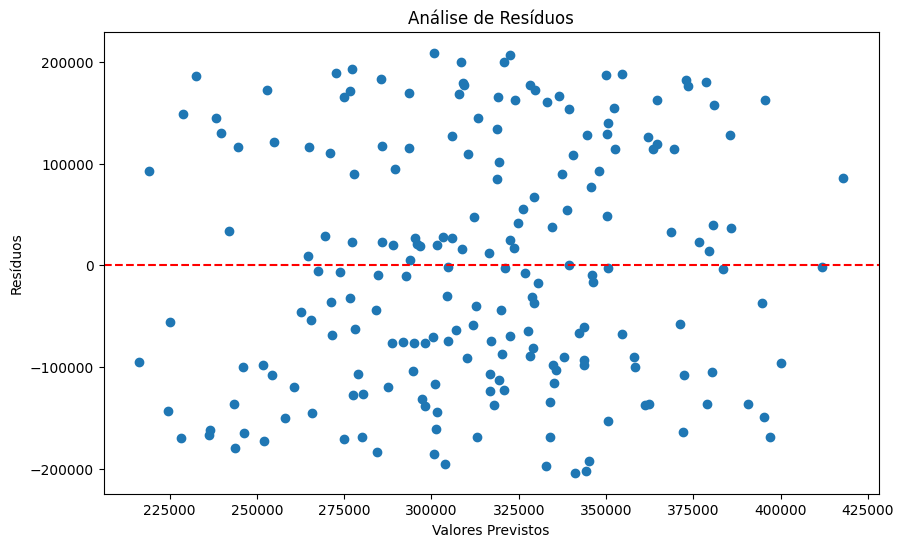

In [119]:
residuos = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle='--', color='red')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Análise de Resíduos')
plt.show()